In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, f1_score,
    precision_score, recall_score, average_precision_score
)
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')
os.makedirs('../models', exist_ok=True)

print('Libraries loaded.')

Libraries loaded.


In [2]:
print('Loading feature data...')
grid = pd.read_parquet('../processed/retailer_day_features.parquet')
print(f'Loaded: {grid.shape}')
grid.head(3)

Loading feature data...
Loaded: (1304640, 27)


,customerId,date,ordered_today,orders_last_7_days,orders_last_14_days,orders_last_30_days,total_orders_so_far,days_since_last_order,avg_gap_between_orders,std_gap_between_orders,...,is_weekend,is_month_start,is_month_end,hubName,shopType,retailerType,app_order_ratio,hubName_enc,shopType_enc,retailerType_enc
0,USR-100,2026-01-01,0,NaN,NaN,NaN,NaN,999.0,12.08,20.48,...,0,1,0,Crossline Events (Noida),Paan A,HVLF,0.9231,3,6,1
1,USR-100,2026-01-02,1,0.0,0.0,0.0,0.0,999.0,12.08,20.48,...,0,1,0,Crossline Events (Noida),Paan A,HVLF,0.9231,3,6,1
2,USR-100,2026-01-03,1,1.0,1.0,1.0,1.0,1.0,12.08,20.48,...,1,1,0,Crossline Events (Noida),Paan A,HVLF,0.9231,3,6,1


In [3]:
FEATURE_COLS = [
    'days_since_last_order',
    'avg_gap_between_orders',
    'std_gap_between_orders',
    'orders_last_7_days',
    'orders_last_14_days',
    'orders_last_30_days',
    'total_orders_so_far',
    'days_overdue',
    'is_overdue',
    'order_regularity',
    'app_order_ratio',
    'day_of_week',
    'day_of_month',
    'week_of_month',
    'month',
    'is_weekend',
    'is_month_start',
    'is_month_end',
    'hubName_enc',
    'shopType_enc',
    'retailerType_enc',
]

TARGET_COL = 'ordered_today'

print(f'Features: {len(FEATURE_COLS)}')
print(f'Target: {TARGET_COL}')

Features: 21
Target: ordered_today


In [4]:
grid['date'] = pd.to_datetime(grid['date'])

TRAIN_END = '2026-04-30'
TEST_START = '2026-05-01'

train = grid[grid['date'] <= TRAIN_END]
test  = grid[grid['date'] >= TEST_START]

print(f'Train rows: {len(train):,} | Positive rate: {train[TARGET_COL].mean()*100:.1f}%')
print(f'Test rows:  {len(test):,}  | Positive rate: {test[TARGET_COL].mean()*100:.1f}%')
print(f'Train period: {train["date"].min().date()} to {train["date"].max().date()}')
print(f'Test period:  {test["date"].min().date()} to {test["date"].max().date()}')

Train rows: 1,036,800 | Positive rate: 12.9%
Test rows:  267,840  | Positive rate: 12.5%
Train period: 2026-01-01 to 2026-04-30
Test period:  2026-05-01 to 2026-05-31


In [5]:
X_train = train[FEATURE_COLS].values
y_train = train[TARGET_COL].values
X_test  = test[FEATURE_COLS].values
y_test  = test[TARGET_COL].values

# Class ratio for scale_pos_weight
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f'Class ratio (neg:pos) in train: {scale_pos_weight:.1f}:1')
print(f'scale_pos_weight for XGBoost: {scale_pos_weight:.2f}')

Class ratio (neg:pos) in train: 6.8:1
scale_pos_weight for XGBoost: 6.77


In [7]:
print('Training Logistic Regression baseline...')

# Fill any remaining NaNs before training
import numpy as np

X_train = np.nan_to_num(X_train, nan=0.0)
X_test  = np.nan_to_num(X_test,  nan=0.0)

# LR needs scaled features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

lr = LogisticRegression(class_weight='balanced', max_iter=500, random_state=42)
lr.fit(X_train_scaled, y_train)

lr_preds = lr.predict(X_test_scaled)
lr_probs = lr.predict_proba(X_test_scaled)[:, 1]

print('\n=== LOGISTIC REGRESSION RESULTS ===')
print(classification_report(y_test, lr_preds, target_names=['No Order', 'Ordered']))

Training Logistic Regression baseline...

=== LOGISTIC REGRESSION RESULTS ===
              precision    recall  f1-score   support

    No Order       0.95      0.78      0.86    234474
     Ordered       0.32      0.74      0.45     33366

    accuracy                           0.77    267840
   macro avg       0.64      0.76      0.65    267840
weighted avg       0.88      0.77      0.81    267840



In [8]:
print('Training XGBoost...')
print('This takes 5-10 minutes on a laptop. Be patient.')

xgb_model = xgb.XGBClassifier(
    n_estimators       = 300,
    max_depth          = 5,
    learning_rate      = 0.05,
    subsample          = 0.8,
    colsample_bytree   = 0.8,
    scale_pos_weight   = scale_pos_weight,  # handles class imbalance
    use_label_encoder  = False,
    eval_metric        = 'logloss',
    random_state       = 42,
    n_jobs             = -1,  # use all CPU cores
    tree_method        = 'hist'  # faster on large datasets
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50  # print progress every 50 rounds
)

print('XGBoost training complete.')

Training XGBoost...
This takes 5-10 minutes on a laptop. Be patient.
[0]	validation_0-logloss:0.67275
[50]	validation_0-logloss:0.44797
[100]	validation_0-logloss:0.42659
[150]	validation_0-logloss:0.40811
[200]	validation_0-logloss:0.39578
[250]	validation_0-logloss:0.38631
[299]	validation_0-logloss:0.37494
XGBoost training complete.


In [9]:
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
xgb_preds = xgb_model.predict(X_test)

print('=== XGBOOST RESULTS (default threshold = 0.5) ===')
print(classification_report(y_test, xgb_preds, target_names=['No Order', 'Ordered']))

=== XGBOOST RESULTS (default threshold = 0.5) ===
              precision    recall  f1-score   support

    No Order       0.96      0.83      0.89    234474
     Ordered       0.39      0.76      0.51     33366

    accuracy                           0.82    267840
   macro avg       0.67      0.79      0.70    267840
weighted avg       0.89      0.82      0.84    267840



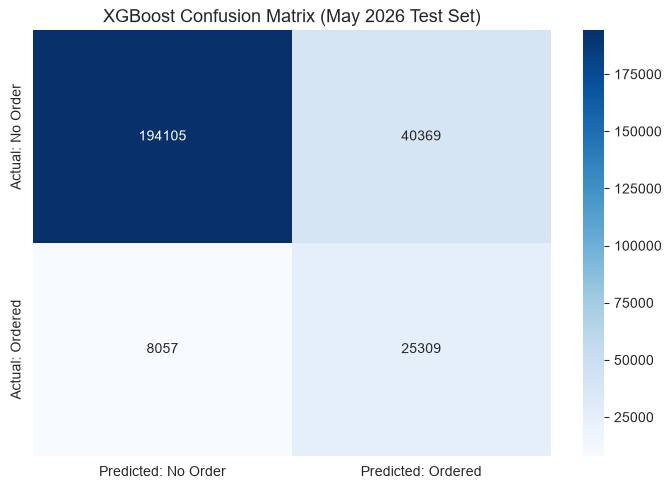

True Positives (correctly predicted orders): 25,309
False Positives (called but no order):       40,369
False Negatives (missed orders):             8,057
True Negatives (correctly skipped):          194,105


In [10]:
# Confusion Matrix
cm = confusion_matrix(y_test, xgb_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: No Order', 'Predicted: Ordered'],
            yticklabels=['Actual: No Order', 'Actual: Ordered'])
plt.title('XGBoost Confusion Matrix (May 2026 Test Set)', fontsize=13)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Positives (correctly predicted orders): {tp:,}')
print(f'False Positives (called but no order):       {fp:,}')
print(f'False Negatives (missed orders):             {fn:,}')
print(f'True Negatives (correctly skipped):          {tn:,}')

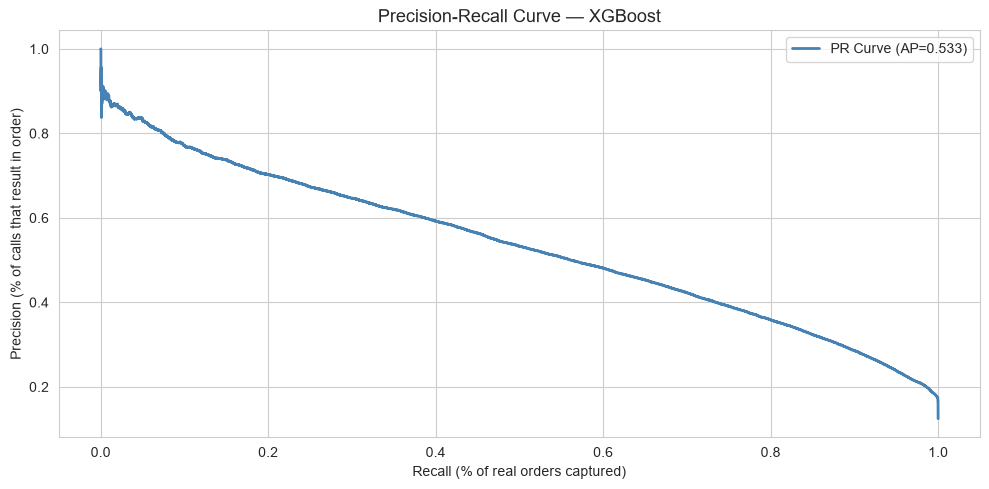

Average Precision Score: 0.5333


In [11]:
# Precision-Recall Curve
precision, recall, thresholds = precision_recall_curve(y_test, xgb_probs)
ap_score = average_precision_score(y_test, xgb_probs)

plt.figure(figsize=(10, 5))
plt.plot(recall, precision, color='steelblue', lw=2, label=f'PR Curve (AP={ap_score:.3f})')
plt.xlabel('Recall (% of real orders captured)')
plt.ylabel('Precision (% of calls that result in order)')
plt.title('Precision-Recall Curve — XGBoost', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

print(f'Average Precision Score: {ap_score:.4f}')

In [12]:
total_retailers_test = test['customerId'].nunique()
total_actual_orders  = y_test.sum()

print(f'Test month (May 2026):')
print(f'  Total retailers: {total_retailers_test:,}')
print(f'  Actual orders placed: {total_actual_orders:,}')
print()

results = []
for threshold in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    preds_t = (xgb_probs >= threshold).astype(int)
    calls_to_make  = preds_t.sum()
    orders_captured = ((preds_t == 1) & (y_test == 1)).sum()
    prec = precision_score(y_test, preds_t, zero_division=0)
    rec  = recall_score(y_test, preds_t, zero_division=0)
    f1   = f1_score(y_test, preds_t, zero_division=0)
    call_reduction = (1 - calls_to_make / total_retailers_test) * 100
    results.append({
        'Threshold': threshold,
        'Calls To Make': calls_to_make,
        'Call Reduction %': f'{call_reduction:.0f}%',
        'Orders Captured': orders_captured,
        'Orders Missed': int(total_actual_orders - orders_captured),
        'Precision': f'{prec*100:.1f}%',
        'Recall': f'{rec*100:.1f}%',
        'F1': f'{f1:.3f}'
    })

threshold_df = pd.DataFrame(results)
print('=== THRESHOLD ANALYSIS TABLE ===')
print(threshold_df.to_string(index=False))

Test month (May 2026):
  Total retailers: 8,640
  Actual orders placed: 33,366

=== THRESHOLD ANALYSIS TABLE ===
 Threshold  Calls To Make Call Reduction %  Orders Captured  Orders Missed Precision Recall    F1
       0.2         134801           -1460%            31768           1598     23.6%  95.2% 0.378
       0.3         107258           -1141%            30208           3158     28.2%  90.5% 0.430
       0.4          83861            -871%            27949           5417     33.3%  83.8% 0.477
       0.5          65678            -660%            25309           8057     38.5%  75.9% 0.511
       0.6          49882            -477%            22174          11192     44.5%  66.5% 0.533
       0.7          36213            -319%            18351          15015     50.7%  55.0% 0.527
       0.8          22027            -155%            13135          20231     59.6%  39.4% 0.474


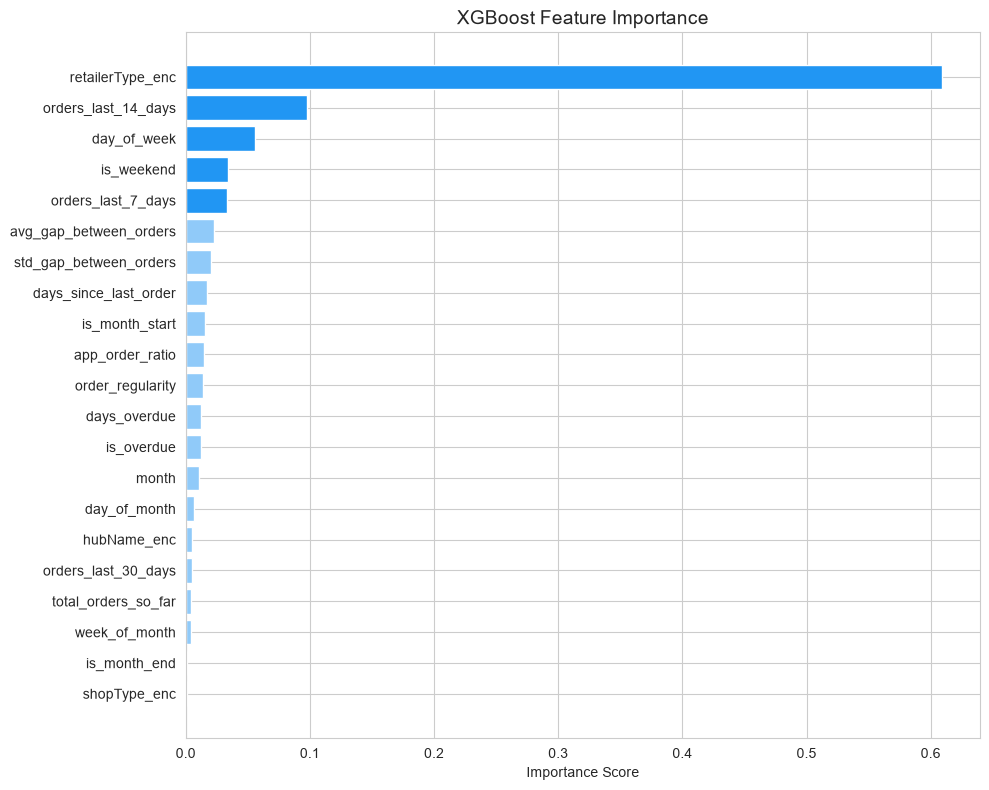

Top 5 most important features:
            Feature  Importance
 orders_last_7_days    0.033604
         is_weekend    0.034074
        day_of_week    0.056077
orders_last_14_days    0.098038
   retailerType_enc    0.609237


In [13]:
importances = xgb_model.feature_importances_
feat_df = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Importance': importances
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 8))
colors = ['#2196F3' if i >= len(feat_df)-5 else '#90CAF9' for i in range(len(feat_df))]
plt.barh(feat_df['Feature'], feat_df['Importance'], color=colors)
plt.title('XGBoost Feature Importance', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Top 5 most important features:')
print(feat_df.tail(5)[['Feature','Importance']].to_string(index=False))

In [14]:
MODEL_PATH = '../models/xgboost_order_model.pkl'

with open(MODEL_PATH, 'wb') as f:
    pickle.dump({
        'model': xgb_model,
        'feature_cols': FEATURE_COLS,
        'threshold': 0.4  # default operating threshold — adjust based on table above
    }, f)

print(f'Model saved to: {MODEL_PATH}')
print()
print('=== TRAINING COMPLETE ===')
print('Next: Run Notebook 4 (Prediction Output)')

Model saved to: ../models/xgboost_order_model.pkl

=== TRAINING COMPLETE ===
Next: Run Notebook 4 (Prediction Output)
